# 03 — Patch extraction

Takes the 139-scene curated list from `02_scene_selection.ipynb` and extracts aligned, native-resolution training patches:

- **`hr_10m`**: 4 x 128 x 128 (B02, B03, B04, B08), native 10m.
- **`hr_20m`**: 6 x 64 x 64 (B05, B06, B07, B8A, B11, B12), native 20m, geographically co-located with the `hr_10m` patch above it.

No downsampling is applied here — patches are saved at native resolution. Wald's-protocol downsampling (to build the actual (input, target) training pairs) happens later, in the training notebook / dataset code, so the downsampling method can be tuned without re-extracting patches.

Each candidate patch is checked against the real Ghana boundary (must be almost entirely inside it) and against the SCL band (must be mostly cloud/shadow/cirrus/snow-free) before being kept — see `s2sr.patches` and `agents.md` "Patch sampling strategy".

This does real windowed reads of full-resolution band data (unlike notebook 2's decimated stats), so it's slower — the notebook is structured to test on one scene, then a small batch, before committing to the full run.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import time
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

sys.path.insert(0, str(Path.cwd().parent / "src"))

from s2sr import config, patches, raster, stac

c:\Users\zutad\miniconda3\envs\s2_dsen2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
scenes = gpd.read_file(config.REPO_ROOT / "data" / "interim" / "s2_scenes_ghana_2025_selected.geojson")
len(scenes)

85

In [4]:
# Fresh search for live signed asset URLs — same reasoning as notebook 2.
items = stac.search_scenes()
items_by_id = {item.id: item for item in items}

missing = set(scenes["id"]) - set(items_by_id)
print(f"{len(scenes)} scenes loaded, {len(missing)} missing from a fresh search (should normally be 0)")

85 scenes loaded, 0 missing from a fresh search (should normally be 0)


In [5]:
ghana_boundary = gpd.read_file(config.GHANA_BOUNDARY_PATH)
patches_dir = config.REPO_ROOT / "data" / "processed" / "patches"
patches_dir

WindowsPath('C:/Users/zutad/Desktop/work_folder/s2_dsen2/data/processed/patches')

## WorldCover fetch test (isolated — not yet wired into extraction)

Land-cover stratification (agents.md open caveat) needs ESA WorldCover data, fetched via `s2sr.landcover`. That module was written without network access to verify Planetary Computer's exact collection id / asset key, so **test it here in isolation first** — a cheap, standalone fetch + plot, nothing to do with patch extraction yet. If this doesn't work (wrong collection id, wrong asset key, unexpected class codes, etc.), report the error back before anything gets wired into `extract_patches_for_scene`.

Expected result: a plot with a handful of distinct color blocks over Ghana — mostly cropland/tree-cover/grassland inland, water along the coast and around Lake Volta. If it's all one color or throws an error, something's wrong with the fetch, not with your setup.

In [ ]:
from rasterio.transform import from_bounds

from s2sr import landcover

bounds_4326 = tuple(ghana_boundary.total_bounds)  # OSM/Nominatim boundary is already EPSG:4326
dst_shape = (512, 512)
dst_transform = from_bounds(*bounds_4326, dst_shape[1], dst_shape[0])

landcover_grid = landcover.fetch_landcover_grid(bounds_4326, "EPSG:4326", dst_transform, dst_shape)

present_classes = sorted(set(np.unique(landcover_grid)) - {0})
print(f"Classes present: {[landcover.WORLDCOVER_CLASSES.get(c, c) for c in present_classes]}")

plt.figure(figsize=(6, 6))
plt.imshow(landcover_grid, cmap="tab20")
plt.title("ESA WorldCover over Ghana AOI (test fetch)")
plt.colorbar(label="class code")

## Step 1 — one scene, visually checked

Extract a handful of patches from a single scene and look at them before trusting the pipeline. `hr_10m` should look like a recognizable true-color patch of Ghana (vegetation/bare soil/water, no obvious artifacts); `hr_20m` bands should be spatially aligned with it (same features, half the pixel dimensions).

In [6]:
sample_item = items_by_id[scenes.iloc[0]["id"]]
sample_records = patches.extract_patches_for_scene(sample_item, ghana_boundary, out_dir=patches_dir, max_patches=5)
print(f"Extracted {len(sample_records)} patches from {sample_item.id}")
pd.DataFrame(sample_records)

Extracted 5 patches from S2B_MSIL2A_20250113T103309_R108_T30NVP_20250113T131928


,patch_id,scene_id,mgrs_tile,datetime,row_off,col_off,aoi_coverage,nodata_fraction,unusable_fraction,path
0,S2B_MSIL2A_20250113T103309_R108_T30NVP_2025011...,S2B_MSIL2A_20250113T103309_R108_T30NVP_2025011...,30NVP,2025-01-13T10:33:09.024000Z,10496,10240,1.0,0.0,0.0,C:\Users\zutad\Desktop\work_folder\s2_dsen2\da...
1,S2B_MSIL2A_20250113T103309_R108_T30NVP_2025011...,S2B_MSIL2A_20250113T103309_R108_T30NVP_2025011...,30NVP,2025-01-13T10:33:09.024000Z,8832,10752,1.0,0.0,0.0,C:\Users\zutad\Desktop\work_folder\s2_dsen2\da...
2,S2B_MSIL2A_20250113T103309_R108_T30NVP_2025011...,S2B_MSIL2A_20250113T103309_R108_T30NVP_2025011...,30NVP,2025-01-13T10:33:09.024000Z,9088,10368,1.0,0.0,0.0,C:\Users\zutad\Desktop\work_folder\s2_dsen2\da...
3,S2B_MSIL2A_20250113T103309_R108_T30NVP_2025011...,S2B_MSIL2A_20250113T103309_R108_T30NVP_2025011...,30NVP,2025-01-13T10:33:09.024000Z,9216,10624,1.0,0.0,0.0,C:\Users\zutad\Desktop\work_folder\s2_dsen2\da...
4,S2B_MSIL2A_20250113T103309_R108_T30NVP_2025011...,S2B_MSIL2A_20250113T103309_R108_T30NVP_2025011...,30NVP,2025-01-13T10:33:09.024000Z,7680,10624,1.0,0.0,0.0,C:\Users\zutad\Desktop\work_folder\s2_dsen2\da...


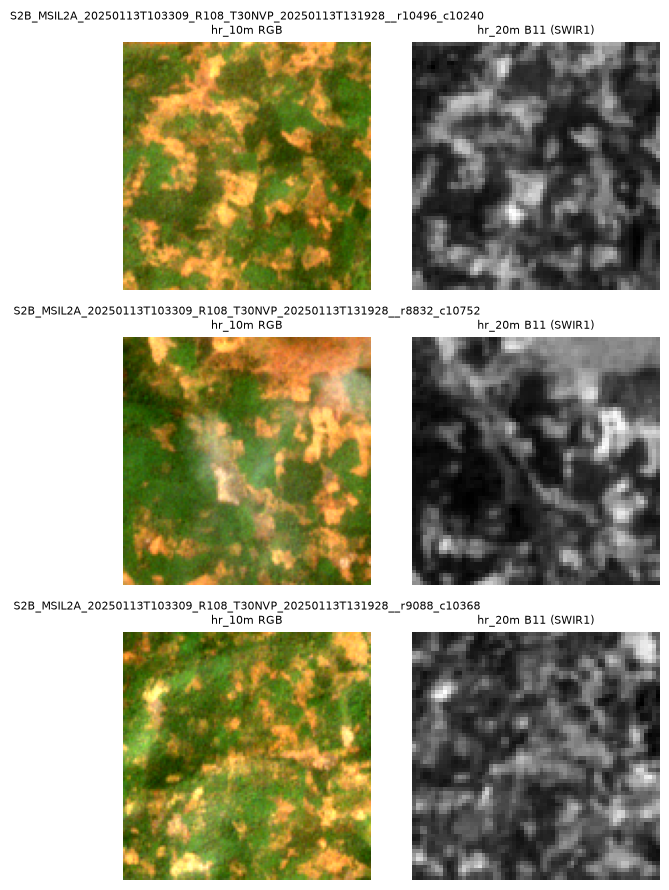

In [7]:
preview_records = sample_records[:3]
fig, axes = plt.subplots(len(preview_records), 2, figsize=(6, 3 * len(preview_records)))
for i, rec in enumerate(preview_records):
    data = np.load(rec["path"])
    hr_10m, hr_20m = data["hr_10m"], data["hr_20m"]
    rgb = raster.percentile_stretch(np.stack([hr_10m[2], hr_10m[1], hr_10m[0]], axis=-1))  # B04,B03,B02
    axes[i, 0].imshow(rgb)
    axes[i, 0].set_title(f"{rec['patch_id']}\nhr_10m RGB", fontsize=8)
    axes[i, 0].axis("off")
    axes[i, 1].imshow(hr_20m[4], cmap="gray")  # B11 (SWIR1)
    axes[i, 1].set_title("hr_20m B11 (SWIR1)", fontsize=8)
    axes[i, 1].axis("off")
fig.tight_layout()

## Step 2 — small batch, to gauge timing

If the previews above look right, run on 5 scenes (not all 139 yet) to get a realistic time-per-scene estimate before committing to the full run.

In [10]:
batch = scenes.sample(5, random_state=0)
start = time.time()
batch_records = []
for _, row in tqdm(batch.iterrows(), total=len(batch)):
    item = items_by_id[row["id"]]
    batch_records.extend(patches.extract_patches_for_scene(item, ghana_boundary, out_dir=patches_dir))
elapsed = time.time() - start

print(f"{len(batch_records)} patches from {len(batch)} scenes in {elapsed:.0f}s")
print(f"Estimated full run (139 scenes): ~{elapsed / len(batch) * 139 / 60:.1f} min")

100%|██████████| 5/5 [14:34<00:00, 174.85s/it]

150 patches from 5 scenes in 874s
Estimated full run (139 scenes): ~405.1 min


## Step 3 — full run

All scenes in the curated list. Per-scene failures are caught and skipped (not aborting the whole run) and reported at the end. Patches already written by steps 1–2 above (or by a previous run of this cell) are reused from disk, not re-downloaded — `extract_patches_for_scene` skips any patch that already exists, and short-circuits entirely (zero network calls) for a scene that already has all its patches. This matters on a metered connection: interrupting and re-running this cell doesn't cost bandwidth for work already done.

**If you already have a full set of patches from before land-cover stratification was added**: the resumable short-circuit means just re-running this cell will NOT retroactively stratify anything — every scene already has `MAX_PATCHES_PER_SCENE` saved, so it's reused as-is. To get a stratified dataset, clear out `data/processed/patches/` (and `data/processed/patches_manifest.csv`) first, then re-run — this re-downloads everything, so only do it deliberately.

In [ ]:
all_records = []
failed_scenes = []  # list of (scene_id, error message)
for _, row in tqdm(scenes.iterrows(), total=len(scenes)):
    item = items_by_id.get(row["id"])
    if item is None:
        failed_scenes.append((row["id"], "not found in fresh STAC search"))
        continue
    try:
        records = patches.extract_patches_for_scene(item, ghana_boundary, out_dir=patches_dir)
    except Exception as e:
        failed_scenes.append((row["id"], f"{type(e).__name__}: {e}"))
        continue
    all_records.extend(records)

print(f"Extracted {len(all_records)} patches from {len(scenes) - len(failed_scenes)}/{len(scenes)} scenes")
print(f"Failed scenes: {len(failed_scenes)}")
for scene_id, error in failed_scenes:
    print(f"  {scene_id}: {error}")

In [12]:
manifest = pd.DataFrame(all_records)
manifest_path = config.REPO_ROOT / "data" / "processed" / "patches_manifest.csv"
manifest.to_csv(manifest_path, index=False)
print(f"Saved manifest: {len(manifest)} patches -> {manifest_path}")

Saved manifest: 2280 patches -> C:\Users\zutad\Desktop\work_folder\s2_dsen2\data\processed\patches_manifest.csv


In [13]:
total_mb = sum(Path(p).stat().st_size for p in manifest["path"]) / 1e6
print(f"Total patch data on disk: {total_mb:.1f} MB across {len(manifest)} patches")
manifest.groupby("mgrs_tile").size().sort_values(ascending=False)

Total patch data on disk: 343.7 MB across 2280 patches


mgrs_tile
30PXQ    150
30PYT    150
30PZT    150
30NZL    120
30PYR    120
30PYQ    120
30NYP    120
30PWS    120
30NXP    120
31PBM    120
30PYS     90
31PBL     90
30PZR     90
30PZS     90
30PWT     90
30NXM     60
30NVP     60
30PWR     60
31NBG     60
30NYM     60
30NYN     60
31NBJ     60
31NBH     60
30PWQ     30
30NXN     30
dtype: int64

## Next steps

- If some tiles have very few or zero patches, check whether `MIN_PATCH_AOI_COVERAGE` (currently 0.95) is too strict for that tile's shape — border tiles may just not have much interior area to work with.
- Notebook 4: train/val split by scene (not by patch — see agents.md), Wald's-protocol pair construction, and the PyTorch training loop.